# Stock Exploration

Pulling historical stock price data and making some basic charts to understand what we're working with before doing any sentiment analysis.

Main research question (for later): does Reddit sentiment predict short-term stock returns better than financial news does?

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

get_stock() is a wrapper around yf.download() so I don't have to retype the same arguments every time. It also drops any rows with missing values. Default date range is 2020-2024 but can be changed.

In [3]:
def get_stock(stock, start = "2020-01-01", end = "2024-12-31"):
    stock = yf.download(stock, start = start, end = end)
    cleaned_stock = stock.dropna()
    return cleaned_stock

compare_stocks() plots closing prices for multiple stocks on the same chart.

In [4]:
def compare_stocks(*stock_names):
    # Ensure at least one stock is provided to prevent plotting errors
    if not stock_names:
        print("Please provide at least one stock name.")
        return
        
    ax = None
    
    # Loop dynamically through all provided stock arguments
    for name in stock_names:
        stock_data = get_stock(name)
        
        # Plot on the existing axes, or create the first one if it doesn't exist
        ax = stock_data["Close"].plot(ax=ax)
        
    plt.legend(stock_names)
    plt.ylabel("Price ($)")
    plt.show()

Downloading 8 tickers. The ones that matter most for the research are GME, TSLA, AAPL, and NVDA - they cover a range from very Reddit-influenced to basically none. KO and PEP are mostly just there as a sanity check since they're in the same industry and neither gets talked about much on Reddit.

In [5]:
apple = get_stock("AAPL")
nvda = get_stock("NVDA")
gme = get_stock("GME")
tsla = get_stock("TSLA")
google = get_stock("GOOGL")
amd = get_stock("AMD")
coke = get_stock("KO")
pepsi = get_stock("PEP")

# ax = apple["Close"].plot(color = "blue")
# nvda["Close"].plot(ax = ax, color = "green")
# gme["Close"].plot(ax = ax, color = "red")
# plt.legend(["AAPL", "NVDA", "GME"])
# plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


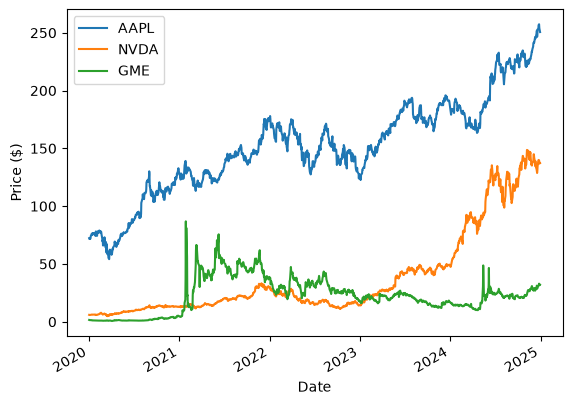

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


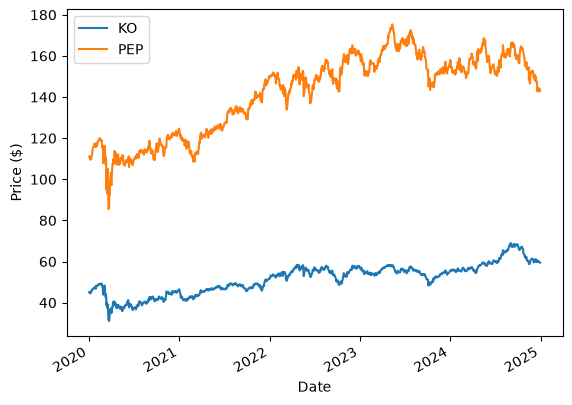

In [11]:
compare_stocks("AAPL", "NVDA", "GME")
compare_stocks("KO", "PEP")

OHLC stands for Open, High, Low, Close. It shows not just where the stock ended the day but how much it moved around in between. The gap between high and low tells you how volatile that specific day was - a wide gap means a lot of price swinging back and forth.

[*********************100%***********************]  1 of 1 completed


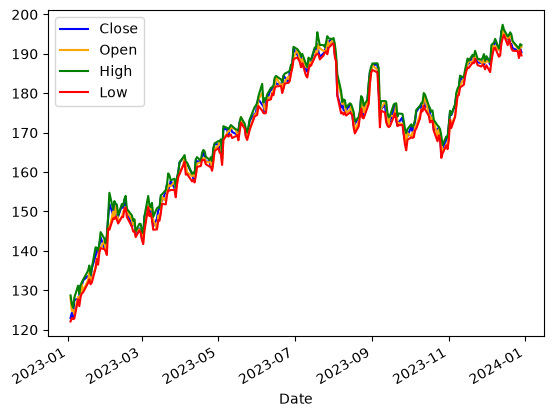

In [7]:
apple_short_term = get_stock("AAPL", start = "2023-01-01", end = "2023-12-31")
ax = apple_short_term["Close"].plot(color = "blue")
apple_short_term["Open"].plot(ax = ax, color = "orange")
apple_short_term["High"].plot(ax = ax, color = "green")
apple_short_term["Low"].plot(ax = ax, color = "red")
plt.legend(["Close", "Open", "High", "Low"])
plt.show()

daily_change() calculates Close - Open for each trading day. Positive = stock closed higher than it opened (green bar), negative = it closed lower (red bar). Running it on GME should show some huge bars around January 2021 when the Reddit short squeeze happened.

In [8]:
def daily_change(stock_name):
    stock = get_stock(stock_name)
    net = stock["Close"][stock_name] - stock["Open"][stock_name]
    # find max net change and date of max net change
    max_change = net.max()
    max_change_date = net.idxmax()
    print(f"Max net change: {max_change} on {max_change_date}")

    # extract the dates (index) and values
    dates = net.index
    values = net.values

    # create the colors
    colors = ["red" if x < 0 else "green" for x in values]

    # create the plot using matplotlib directly (handles dates correctly)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(dates, values, color=colors, width=0.8) # Adjust width as needed

    # set X-axis to show exactly one tick per month
    ax.xaxis.set_major_locator(mdates.YearLocator())

    # format the tick labels to "Month Year" (e.g., "Jan 2020")
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    # Clean up layout and rotate labels slightly for clean viewing
    plt.ylabel("Net Change ($)")
    plt.title(f"Daily Net Change for {stock_name}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

[*********************100%***********************]  1 of 1 completed


Max net change: 15.065000534057617 on 2021-03-25 00:00:00


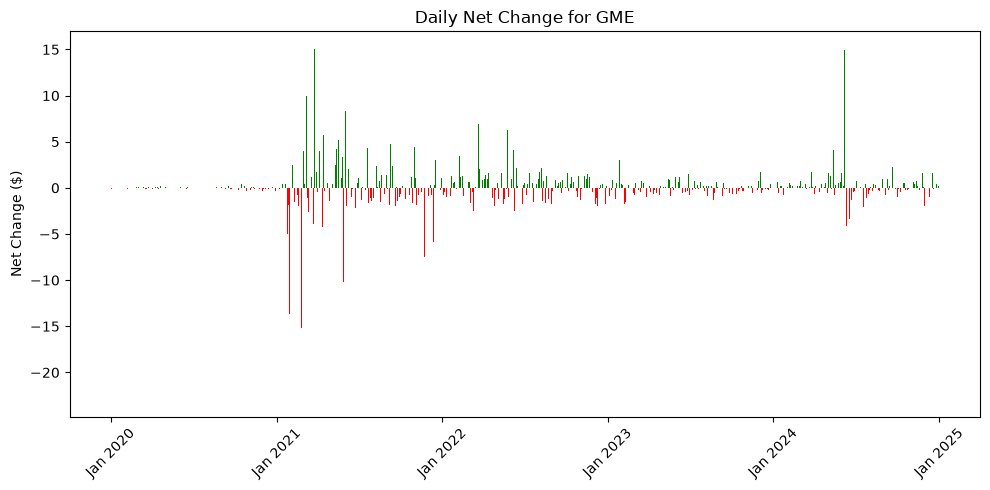

[*********************100%***********************]  1 of 1 completed


Max net change: 13.384061816844138 on 2024-06-11 00:00:00


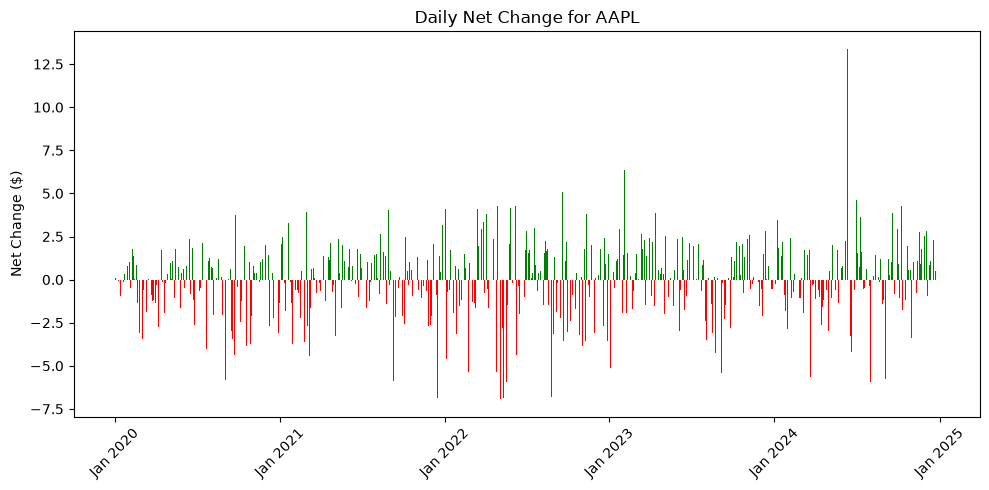

[*********************100%***********************]  1 of 1 completed


Max net change: 33.46000671386719 on 2022-02-24 00:00:00


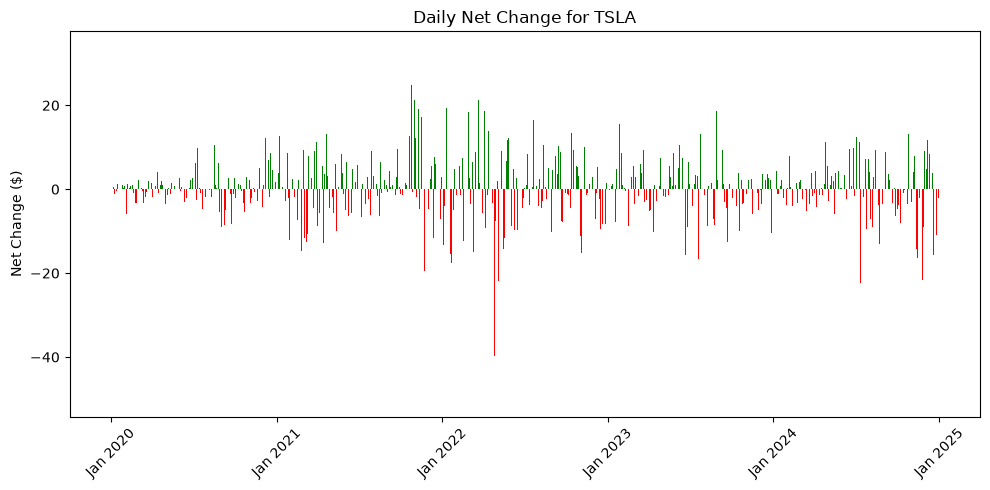

In [9]:
daily_change("GME")
daily_change("AAPL")
daily_change("TSLA")

Saving everything to CSV files so I don't have to re-download every time I open the notebook.

In [10]:
apple.to_csv("../data/aapl.csv")
nvda.to_csv("../data/nvda.csv")
gme.to_csv("../data/gme.csv")
tsla.to_csv("../data/tsla.csv")
google.to_csv("../data/google.csv")
amd.to_csv("../data/amd.csv")  
coke.to_csv("../data/coke.csv")
pepsi.to_csv("../data/pepsi.csv")

---

What's next: collect Reddit posts mentioning these stocks and run sentiment analysis on them. Then match the sentiment scores to the price data day by day to see if there's a relationship.

One thing I'll need to add to the price data later: "forward returns" - basically, what did the stock price do 1, 3, or 5 days after each Reddit post was made? That's what the sentiment score is supposed to predict. So if someone posts bullishly about GME on a Tuesday, did the price actually go up on Wednesday?